# Team 08 - Uncertainty-Aware Active Vision for UAV Bridge Inspection - Live Demo
Same demos as `run_demo.py`. Every cell calls a demo's `main()` (all logic lives in `demo_core`), prints the narrated terminal output, then shows the GIF / PNG that run just produced in `backup/`.

Guideline steps: **1** start env, **2** observation, **3** actions + selection, **4** env response, **5** reward + next state, **6** learning update, **7** trained policy, **8** curves + metrics.

In [1]:
import sys, os
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT)); os.chdir(ROOT)
from IPython.display import Image, display
from demo_core import paths
def show(name):
    for kind in ('gifs', 'frames', 'snapshots'):
        p = paths.out_dir(kind) / name
        if p.exists():
            return display(Image(filename=str(p)))
    print('not found:', name)
SEED = ['--seed', str(paths.default_seed())]

## Demo 1 - Environment tour (guideline 1, 2, 4)

─────────────────────────────────────────────────── DEMO 1 - Environment tour ────────────────────────────────────────────────────

InspectionEnv: UAV inspecting a bridge surface

 GUIDELINE 1  Start the environment

mode=navigate   obs Box(0.0, 1.0, (118,), float32)  action Discrete(6)  max steps 200

mode=refine     obs Box([ 0. -1. -1.  0.  0.  0.], 1.0, (6,), float32)  action Box(-1.0, 1.0, (3,), float32)  max steps 30

...

Detector modes: uncertainty u per view quality q (lower = better view)                                                            
┏━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃   ┃         analytic u ┃                    ┃                    ┃                    ┃                   ┃     learned detect ┃
┃ q ┃           (defect) ┃ analytic u (clean) ┃ analytic P(detect) ┃ learned u (defect) ┃ learned u (clean) ┃               rate ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ 0 │               0.90 │               0.80 │               0.20 │               0.60 │              0.32 │               0.40 │
│ 1 │               0.75 │               0.50 │               0.50 │               0.56 │              0.23 │               0.82 │
│ 2 │               0.55 │               0.30 │               0.80 │               0.54 │              0.18 │               0.93 │
│ 3 │               0.30 │               0.15 │               0.95 │               0.53 │              0.15 │               0.97 │
│ 4 │               0.08 │               0.05 │               0.99 │               0.53 │              0.14 │               0.98 │
└───┴────────────────────┴────────────────────┴────────────────────┴────────────────────┴───────────────────┴────────────────────┘

 GUIDELINE 2  Observation after reset (ASCII render: U = UAV, . = unseen, digit = uncertainty x 10)

5344............
3244............
5555............
4575............
7575............
3355............
U347............
2245............
alt=mid battery=0.88

saved env_tour.gif (0.2 MB, 21 frames, 5s)

 GUIDELINE 4  Random rollout: 20 steps, return -3.17, coverage 25%

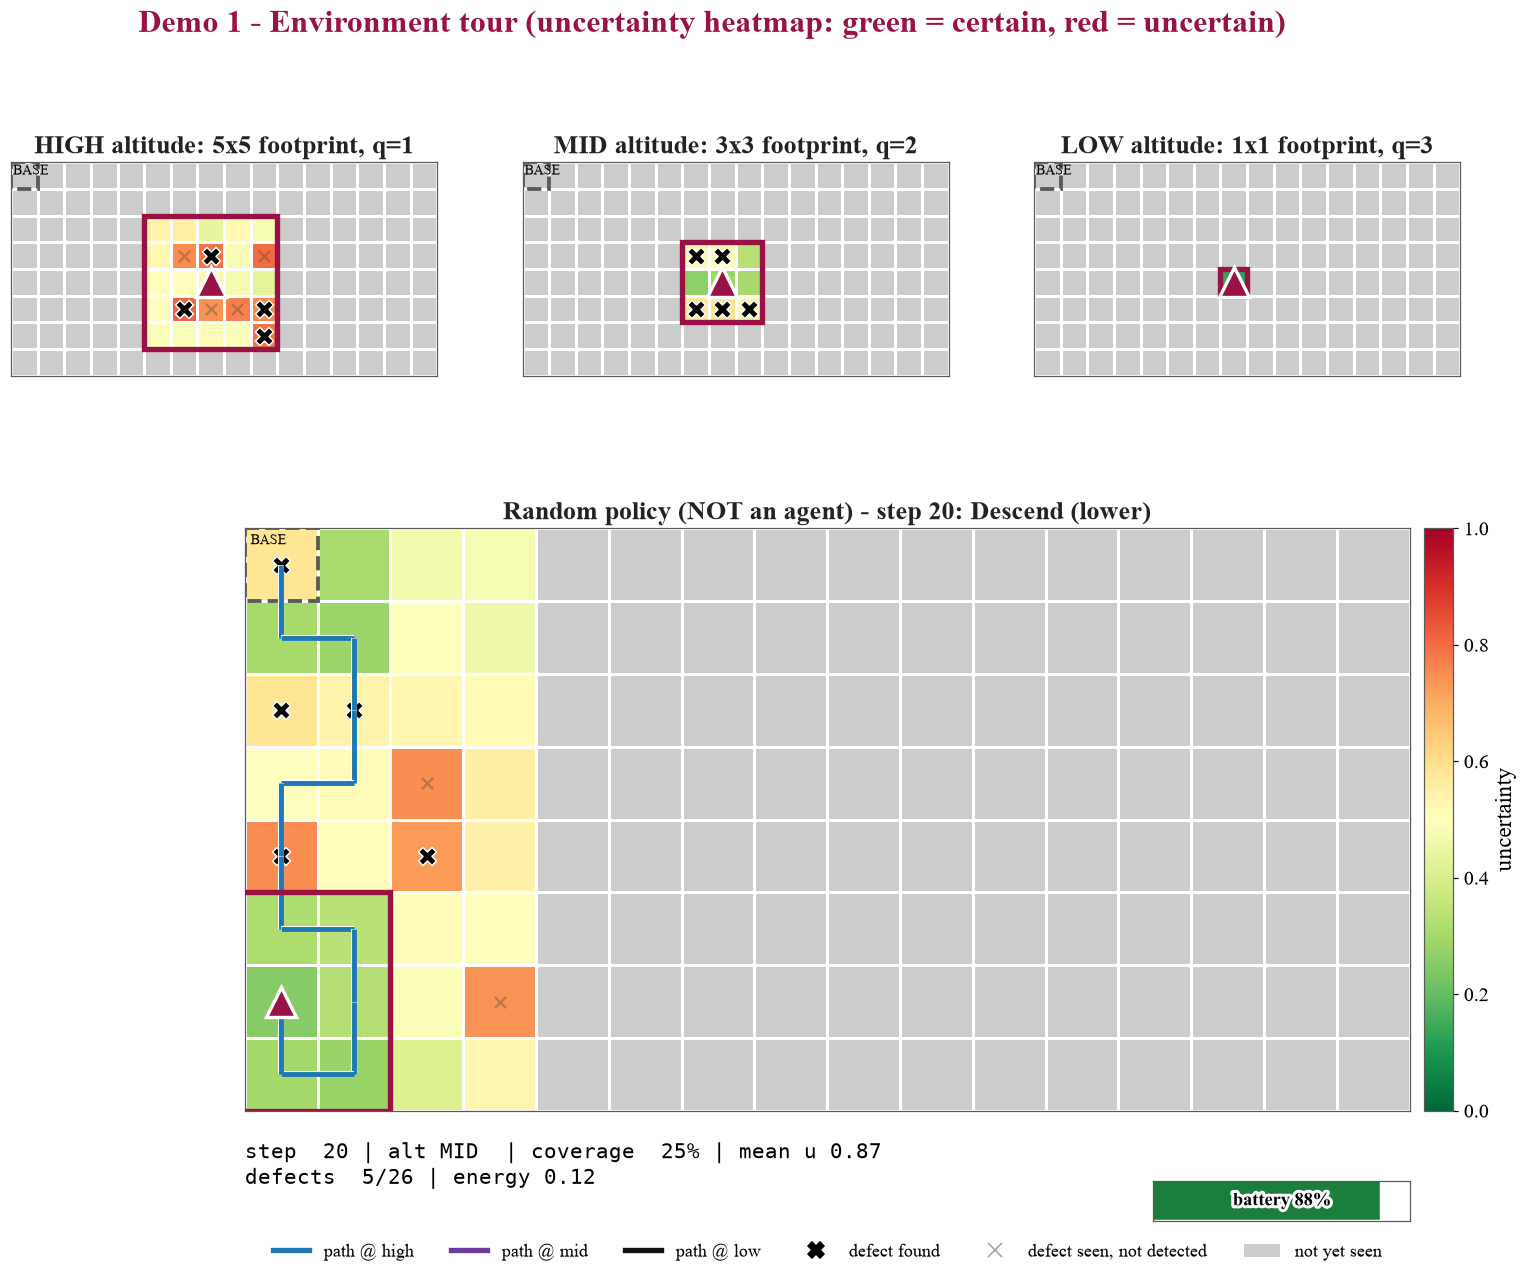

In [2]:
import demos.d1_env_tour as d1
d1.main(['--save', '--fast'] + SEED)
show('env_tour_final.png')

## Demo 2 - Agent A (DQN) step-through (guideline 2-5, 7, 8)

───────────────────────────────────────────────── DEMO 2 - Agent A step-through ──────────────────────────────────────────────────

Agent A - Viewpoint Planner (DQN)   seed 1000   detector analytic

 GUIDELINE 1  Environment started: InspectionEnv(mode='navigate'), bridge seed 1000

model: L:\My Drive\RL_Project\files_coding\uav_inspection\agentA\best\best_model.zip

 GUIDELINE 2  Current observation / state

...

t= 81  West                   r= +0.06  alt=LOW  cov=100.0%  u=0.322  defects=24/26  battery=0.52

t= 82  West                   r=+20.46  alt=LOW  cov=100.0%  u=0.319  defects=24/26  battery=0.52

 GUIDELINE 8  Final performance of this episode (live) vs saved 20-episode evaluation

Agent A - results (saved rows: mean of 20 seeded bridges,                        
agentA_vs_baselines.csv)                                                         
┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┓
┃ run                  ┃ return ┃ success ┃ steps ┃ coverage ┃ defects ┃ energy ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━┩
│ this episode (live)  │ +35.97 │    True │    82 │     100% │   24/26 │  0.480 │
│ saved: DQN (Agent A) │ +35.06 │    100% │  88.3 │     100% │    21.8 │  0.502 │
│ saved: raster_mid    │  +6.20 │      0% │ 199.0 │     100% │    20.9 │  1.000 │
│ saved: raster_low    │ +35.43 │    100% │ 123.0 │      95% │    23.5 │  0.625 │
└──────────────────────┴────────┴─────────┴───────┴──────────┴─────────┴────────┘

Learning / update step (guideline 6): run demo 8 (live training burst).

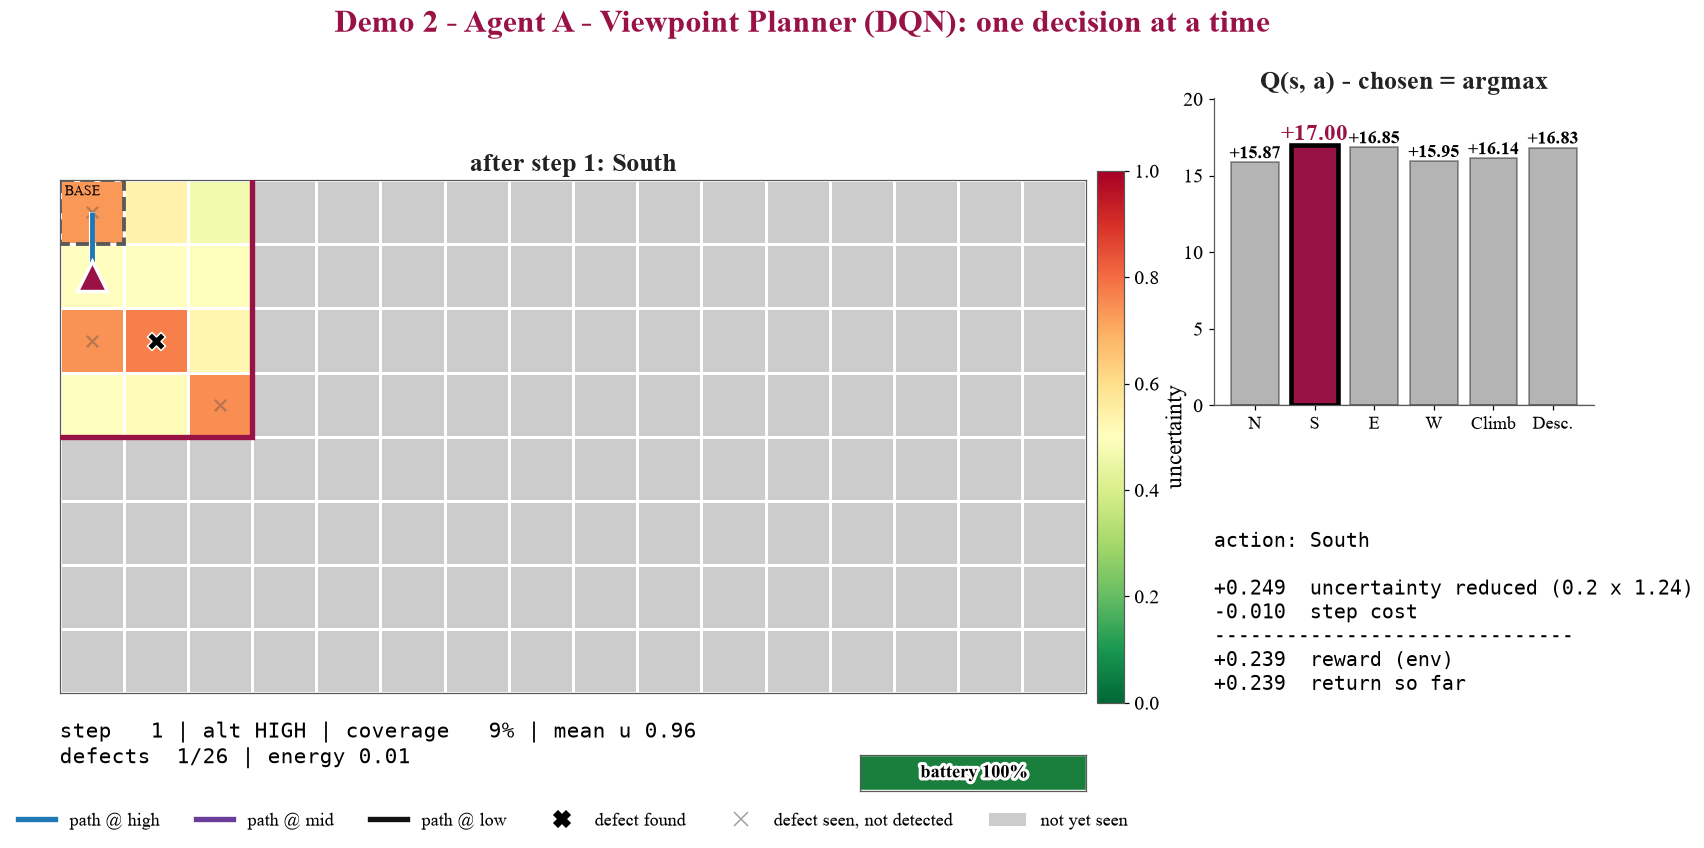

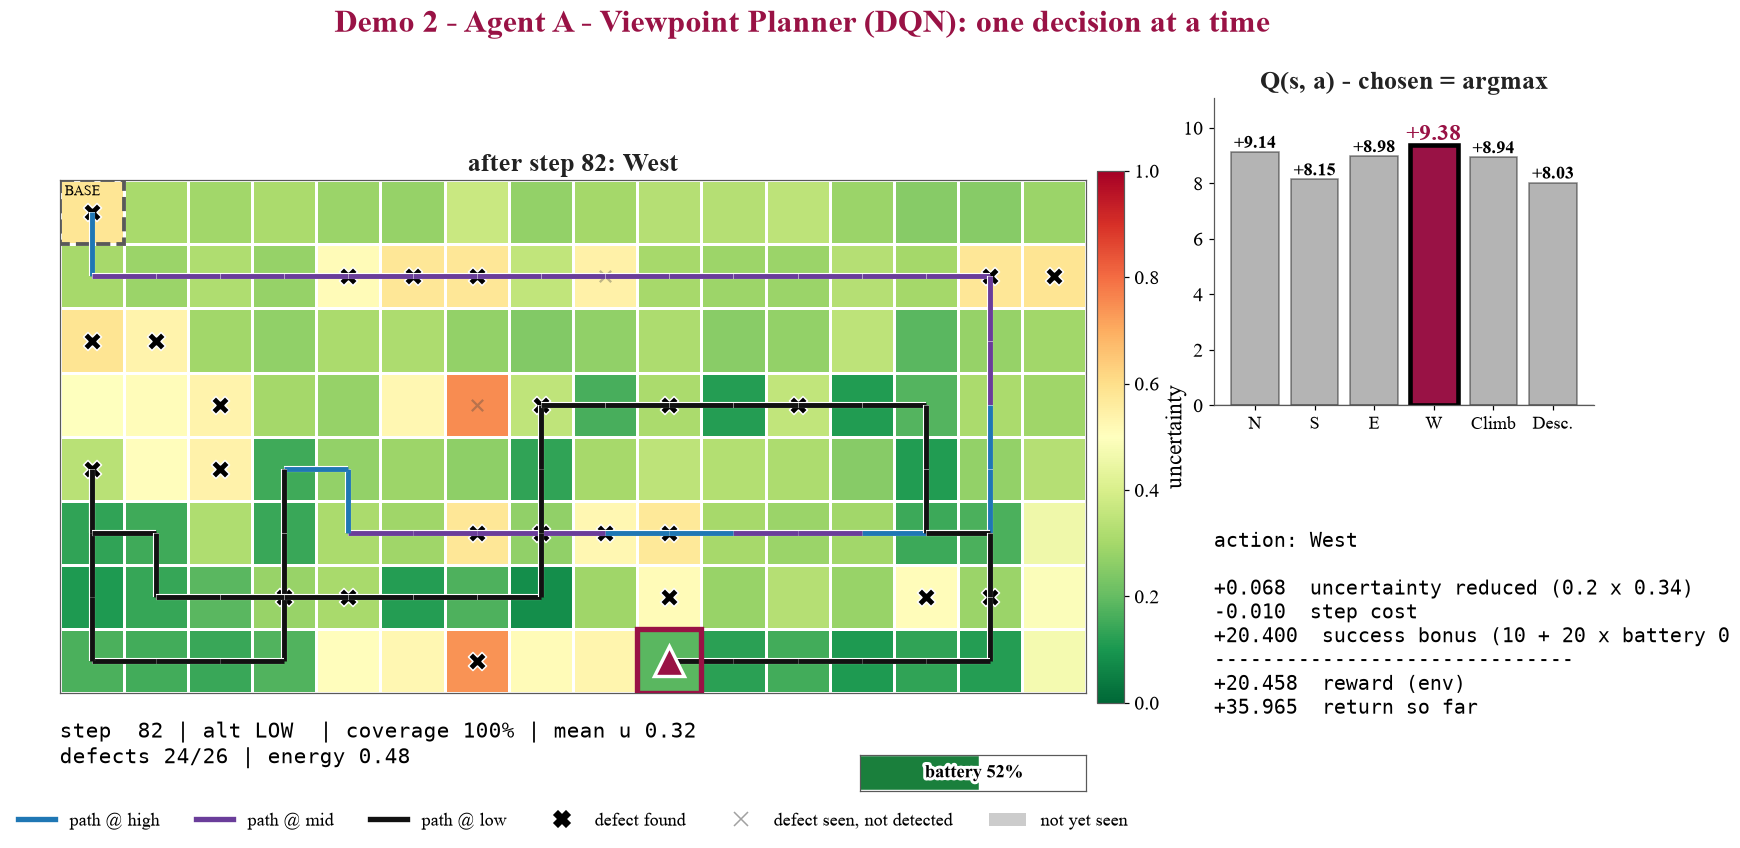

In [3]:
import demos.d2_agentA_step as d2
d2.main(['--save', '--auto'] + SEED)
show('agentA_step1.png')
show('agentA_final.png')

## Demo 3 - Agent A vs dense raster, same bridge (guideline 7, 8)

─────────────────────────────────────────────────── DEMO 3 - Agent A vs raster ───────────────────────────────────────────────────

same seed 1000 -> same bridge for both

 GUIDELINE 1  Two identical environments (navigate mode, seed 1000, detector analytic)

 GUIDELINE 7  Trained policy vs scripted baseline, animated

saved agentA_vs_raster.gif (0.6 MB, 70 frames, 19s)

 GUIDELINE 8  Final performance on this bridge (live)

Seed 1000: live results                                                                                 
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┓
┃ policy                             ┃ steps ┃ energy ┃ coverage ┃ mean u ┃ defects ┃ success ┃ return ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━┩
│ Agent A - Viewpoint Planner (DQN)  │    82 │  0.480 │     100% │  0.319 │   24/26 │     yes │ +35.97 │
│ BASELINE Dense raster, LOW altitud │   123 │  0.625 │      95% │  0.219 │   26/26 │     yes │ +35.52 │
└────────────────────────────────────┴───────┴────────┴──────────┴────────┴─────────┴─────────┴────────┘

Agent A on this bridge: -33% steps, -23% energy vs dense raster  (defects found 24 vs 26)

Saved evaluation (mean of 20 seeded bridges) - agentA_vs_baselines.csv                 
┏━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━┳━━━━━━━━┓
┃ policy        ┃      return ┃ success ┃ steps ┃ coverage ┃ defects ┃  mIoU ┃ energy ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━╇━━━━━━━━┩
│ DQN (Agent A) │ 35.1 +- 4.0 │    100% │  88.3 │     100% │    21.8 │ 0.539 │  0.502 │
│ raster_mid    │  6.2 +- 0.1 │      0% │ 199.0 │     100% │    20.9 │ 0.500 │  1.000 │
│ raster_low    │ 35.4 +- 0.1 │    100% │ 123.0 │      95% │    23.5 │ 0.626 │  0.625 │
└───────────────┴─────────────┴─────────┴───────┴──────────┴─────────┴───────┴────────┘

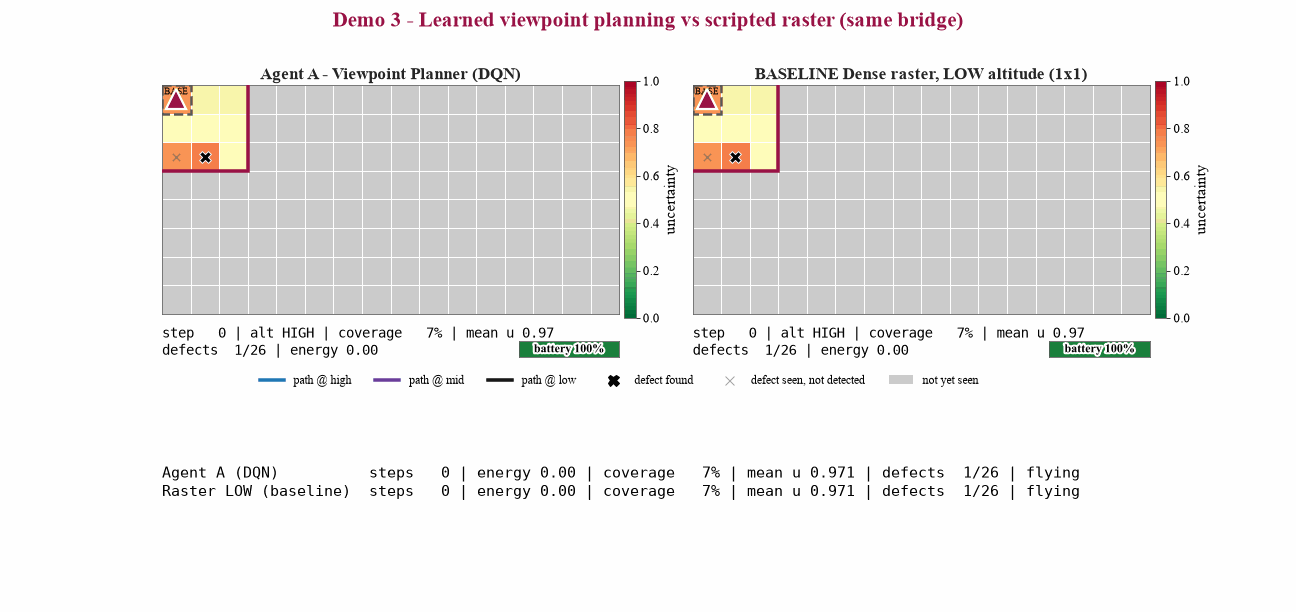

In [4]:
import demos.d3_agentA_vs_raster as d3
d3.main(['--save'] + SEED)
show('agentA_vs_raster.gif')

## Demo 4 - Agent B (PPO) view refinement vs FixedOrbit (guideline 2-5, 7, 8)

──────────────────────────────────────────────── DEMO 4 - Agent B view refinement ────────────────────────────────────────────────

Agent B - View Refiner (PPO) vs FixedOrbit baseline, same seeds

 GUIDELINE 1  Environment started: InspectionEnv(mode='refine') - hover near ONE uncertain cell

Target 1 (seed 1000): cell (2, 5), start d=0.83 angle=-0.28 lateral=+0.13  s=0.35

 GUIDELINE 2  Observation (6 numbers)

...

 GUIDELINE 7  Trained policy on each target, animated next to the baseline

saved agentB_refine.gif (0.3 MB, 60 frames, 24s)

 GUIDELINE 8  Final performance (live, same seeds)

Agent B vs FixedOrbit - live                                                             
┏━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ seed      ┃                       policy ┃ steps ┃ success ┃ best q ┃ energy ┃ return ┃
┡━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ seed 1000 │ Agent B - View Refiner (PPO) │     4 │     yes │     q4 │  0.032 │  +5.56 │
│ seed 1000 │          BASELINE FixedOrbit │    30 │      no │     q2 │  0.240 │  -2.36 │
│ seed 1001 │ Agent B - View Refiner (PPO) │     3 │     yes │     q4 │  0.024 │  +5.73 │
│ seed 1001 │          BASELINE FixedOrbit │    30 │      no │     q2 │  0.240 │  -2.09 │
│ seed 1002 │ Agent B - View Refiner (PPO) │     4 │     yes │     q4 │  0.032 │  +5.78 │
│ seed 1002 │          BASELINE FixedOrbit │    30 │      no │     q2 │  0.240 │  -2.17 │
└───────────┴──────────────────────────────┴───────┴─────────┴────────┴────────┴────────┘

Saved evaluation (mean of 50 seeded targets) - agentB_vs_baselines.csv      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━┳━━━━━━━━┓
┃ policy                          ┃      return ┃ success ┃ steps ┃ energy ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━╇━━━━━━━━┩
│ PPO (Agent B)                   │  5.7 +- 0.1 │    100% │   3.7 │  0.029 │
│ fixed_orbit                     │ -2.3 +- 0.1 │      0% │  30.0 │  0.240 │
│ random                          │ -2.0 +- 1.1 │      2% │  29.8 │  0.239 │
│ scripted_approach (upper bound) │  5.7 +- 0.1 │    100% │   3.6 │  0.029 │
└─────────────────────────────────┴─────────────┴─────────┴───────┴────────┘

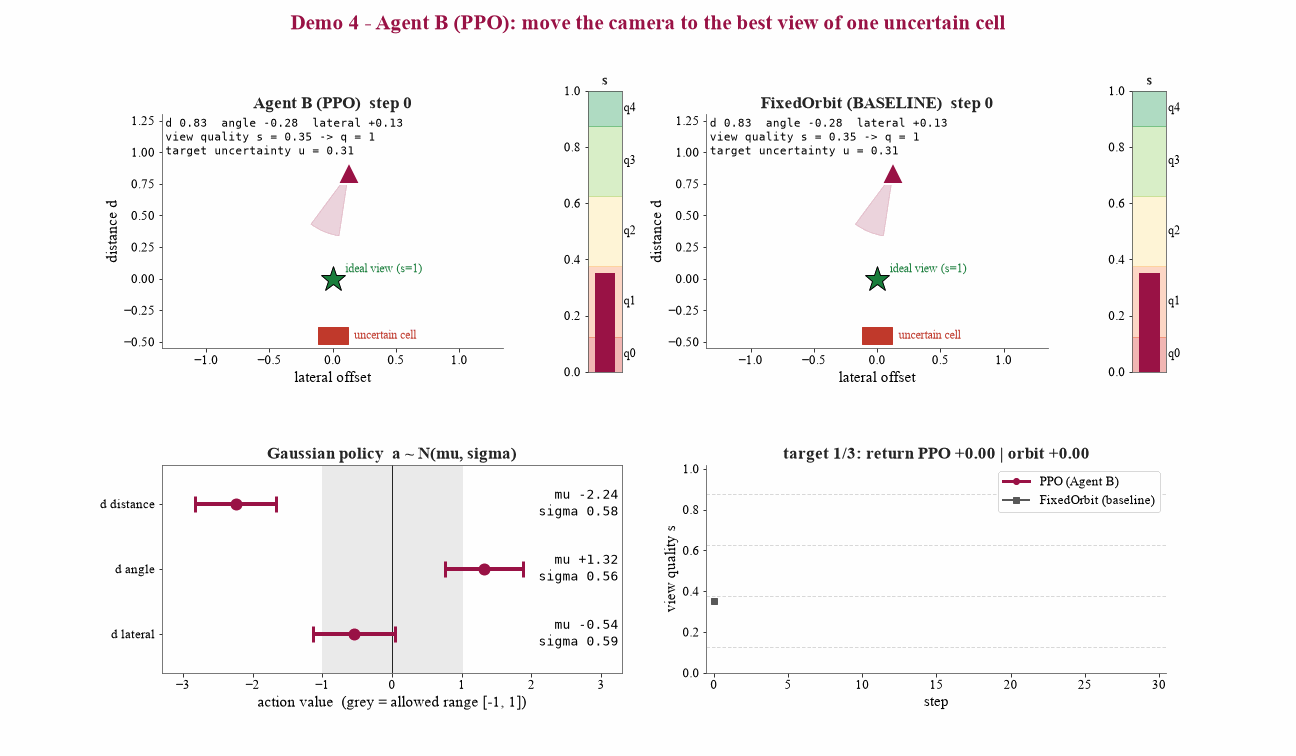

In [5]:
import demos.d4_agentB_refine as d4
d4.main(['--save'] + SEED)
show('agentB_refine.gif')

## Demo 5 - Real-image detector: U-Net + MC-dropout on DeepCrack TEST patches

────────────────────────────────────────────────── DEMO 5 - Real-image detector ──────────────────────────────────────────────────

DeepCrack -> U-Net with MC-dropout -> per-cell uncertainty

Saved detector report (detector_report.json: 1200 crack + 1800 clean TEST patches,
10 MC passes)                                                                     
┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ q ┃ resolution ┃ u (crack) ┃ u (clean) ┃ detect rate ┃ false pos ┃ IoU (crack) ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ 0 │       4 px │     0.601 │     0.321 │       39.8% │      0.9% │       0.193 │
│ 1 │       8 px │     0.563 │     0.234 │       82.2% │      2.4% │       0.501 │
│ 2 │      16 px │     0.543 │     0.179 │       92.8% │      4.8% │       0.644 │
│ 3 │      32 px │     0.532 │     0.153 │       96.9% │      7.3% │       0.696 │
│ 4 │      64 px │     0.526 │     0.140 │       98.2% │     12.5% │       0.717 │
└───┴────────────┴───────────┴───────────┴─────────────┴───────────┴─────────────┘

env mapping (learned mode): altitude HIGH/MID/LOW -> q0/q1/q3;  q4 only through Agent B's refinement.

 GUIDELINE 1  U-Net loaded from unet_deepcrack.pt; 3 patches from the DeepCrack TEST split

...

CLEAN patch 11247-1.jpg @(192,320)                        
┏━━━┳━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━┳━━━━━━━━━━┓
┃ q ┃  res ┃ entropy u (bits) ┃ MC std ┃  IoU ┃ detected ┃
┡━━━╇━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━╇━━━━━━━━━━┩
│ 0 │  4px │            0.058 │  0.014 │ 1.00 │       no │
│ 1 │  8px │            0.008 │  0.001 │ 1.00 │       no │
│ 2 │ 16px │            0.019 │  0.003 │ 1.00 │       no │
│ 3 │ 32px │            0.011 │  0.001 │ 1.00 │       no │
│ 4 │ 64px │            0.034 │  0.012 │ 1.00 │       no │
└───┴──────┴──────────────────┴────────┴──────┴──────────┘

 GUIDELINE 4  Same patch seen at q0 (far/high) ... q4 (Agent B's best view)

saved detector.gif (0.5 MB, 17 frames, 7s)

 GUIDELINE 8  What the saved evaluation says (detector_report.json)

Per patch, raw MC entropy is NOT monotone in q (51% of q-steps rise before fusion; at q0 the net can be confidently wrong, IoU 
0).
   The cache therefore rank-normalises u and applies best-view fusion (running min over q).
   Over 1200 crack patches: u 0.60 -> 0.53, detect rate 40% -> 98%, IoU 0.19 -> 0.72 from q0 to q4 (false positives 0.9% -> 
12.5%).

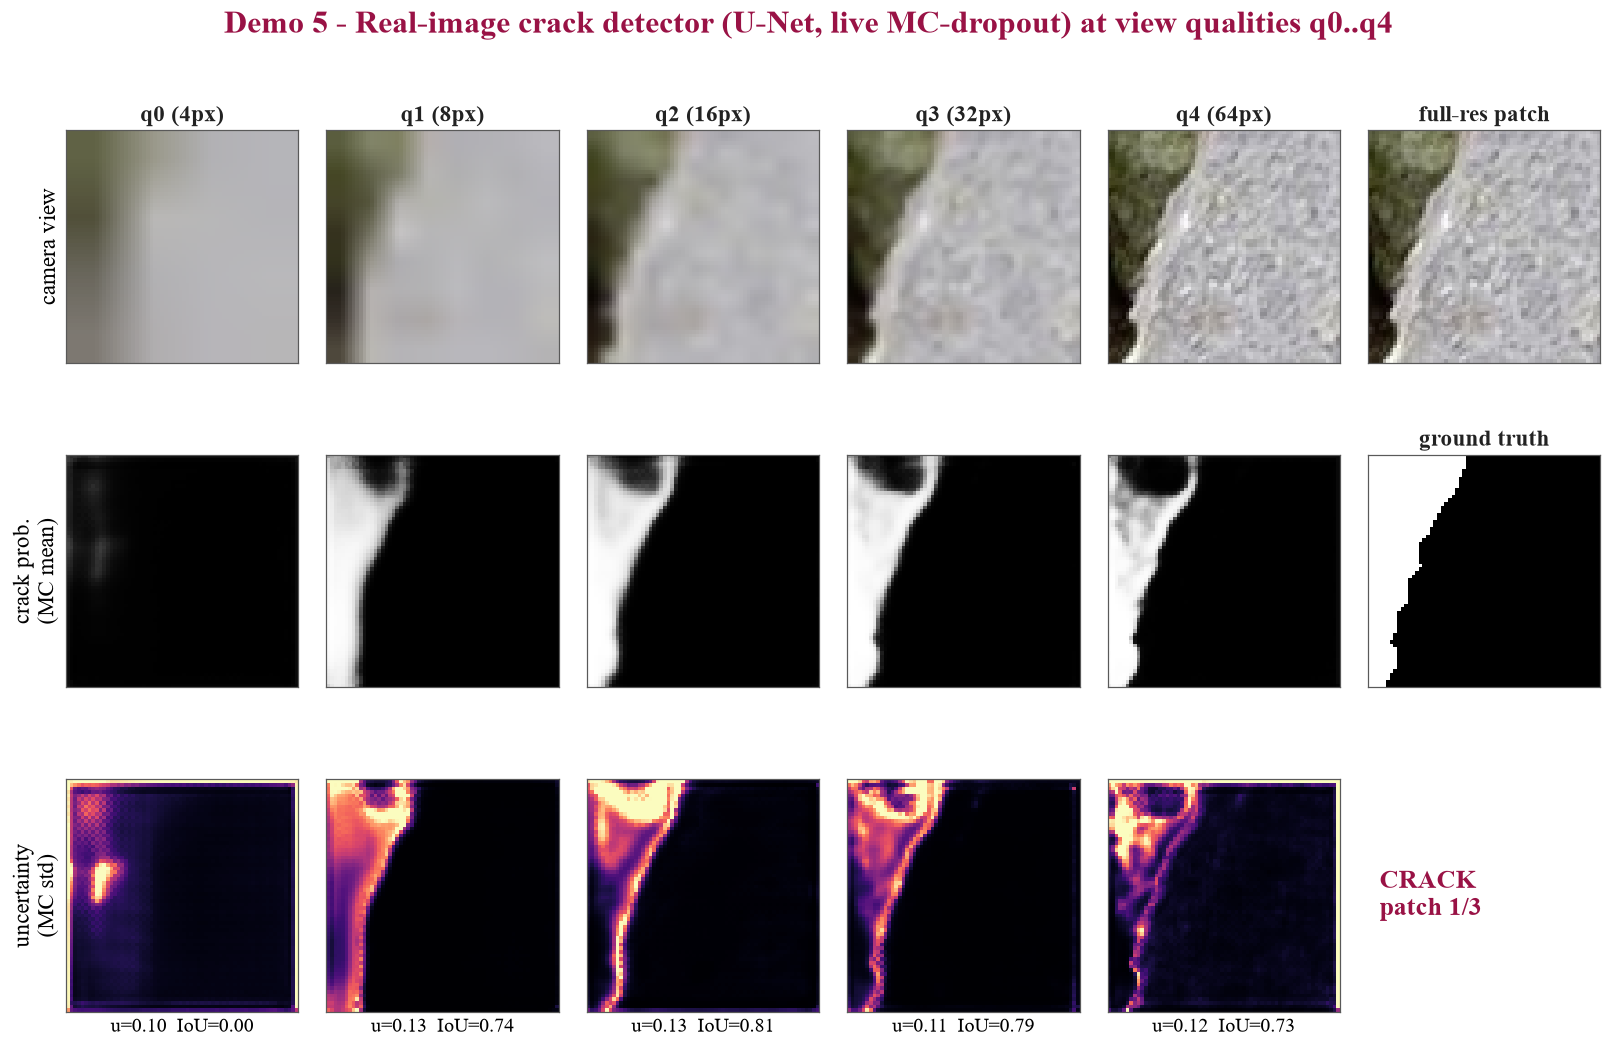

In [6]:
import demos.d5_detector_views as d5
d5.main(['--save'] + SEED)
show('detector_crack.png')

## Demo 6 - Agent C (A2C) mission supervisor (guideline 2-5, 7, 8)

────────────────────────────────────────────── DEMO 6 - Agent C mission supervisor ───────────────────────────────────────────────

Agent C - Mission Supervisor (A2C)   seed 1000

 GUIDELINE 1  Environment started: InspectionEnv(mode='supervise'); inside options: scripted RasterNav (explore) + ApproachRefiner
(refine) - exactly as Agent C was trained

 GUIDELINE 2  Supervisor state before decision 0

OBSERVATION  s_t (6 numbers in [0, 1])                                 
┏━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ battery ┃ coverage ┃ mean u ┃ found frac ┃ dist to base ┃ time used ┃
┡━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│   1.000 │    0.070 │  0.971 │      0.038 │        0.000 │     0.000 │
└─────────┴──────────┴────────┴────────────┴──────────────┴───────────┘

...

saved agentC_mission.gif (0.5 MB, 56 frames, 20s)

 GUIDELINE 8  Final performance on this bridge (live) + saved 20-bridge evaluation

option counts: {'EXPLORE': 17, 'REFINE': 0, 'RETURN': 1}

Seed 1000: live                                                                                        
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ supervisor                         ┃ decisions ┃ return ┃ defects ┃ energy ┃ coverage ┃ safe return ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ Agent C - Mission Supervisor (A2C) │        18 │ +47.74 │      25 │  0.510 │     100% │         yes │
│ BASELINE RuleSupervisor            │        34 │ +49.52 │      26 │  0.962 │     100% │         yes │
└────────────────────────────────────┴───────────┴────────┴─────────┴────────┴──────────┴─────────────┘

Saved evaluation (mean of 20 seeded bridges) - agentC_vs_baselines.csv                       
┏━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━┳━━━━━━━━┓
┃ policy          ┃      return ┃ success ┃ decisions ┃ coverage ┃ defects ┃  mIoU ┃ energy ┃
┡━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━╇━━━━━━━━┩
│ A2C (Agent C)   │ 39.8 +- 3.4 │    100% │      19.2 │     100% │    20.9 │ 0.500 │  0.510 │
│ rule_supervisor │ 42.8 +- 3.0 │    100% │      33.8 │     100% │    22.6 │ 0.597 │  0.954 │
│ random          │  4.1 +- 9.1 │    100% │       3.0 │      16% │     3.0 │ 0.072 │  0.066 │
└─────────────────┴─────────────┴─────────┴───────────┴──────────┴─────────┴───────┴────────┘

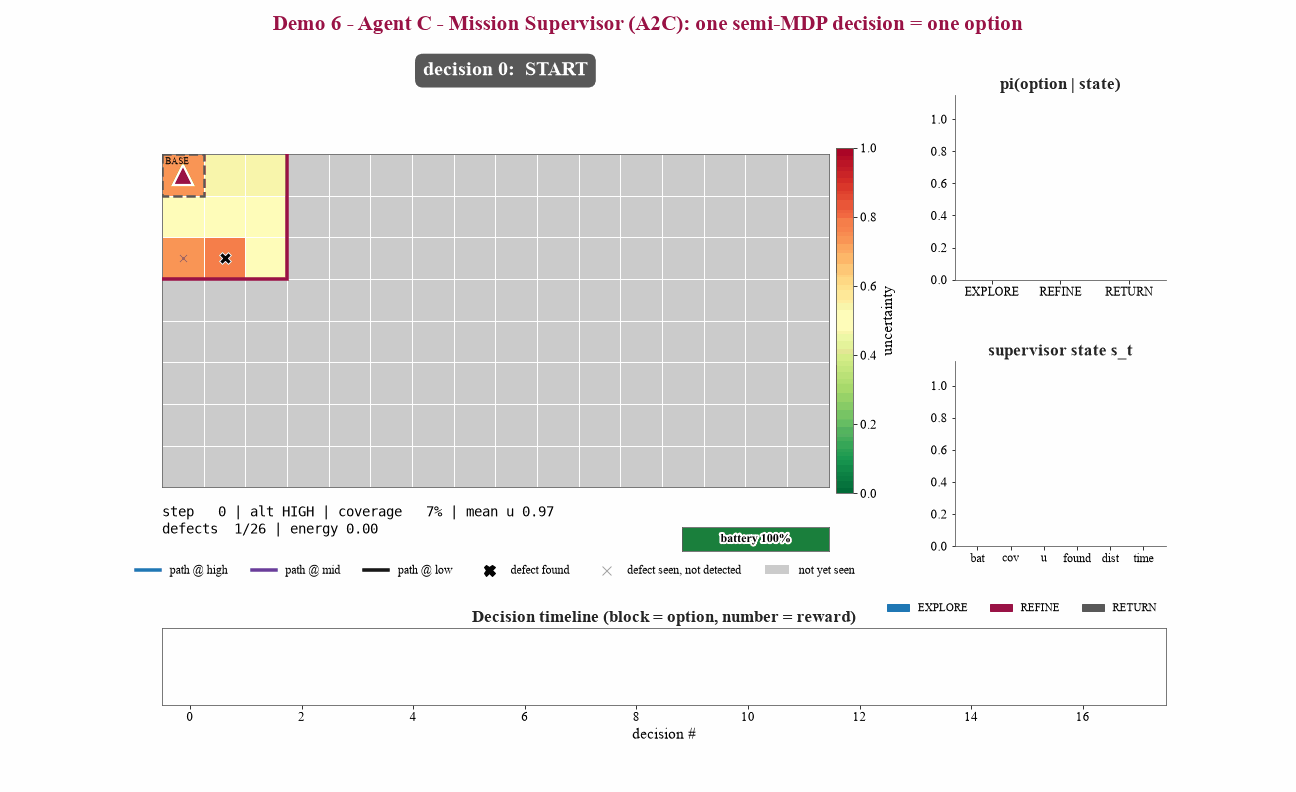

In [7]:
import demos.d6_agentC_mission as d6
d6.main(['--save'] + SEED)
show('agentC_mission.gif')

## Demo 7 - Full hierarchy: C -> A / B vs all-scripted (guideline 7, 8)
The trained supervisor never picks REFINE (true on all 20 evaluation bridges), so the second run uses the rule supervisor to show Agent B inside the hierarchy.

─────────────────────────────────────────────── DEMO 7 - Full hierarchical mission ───────────────────────────────────────────────

supervisor: Agent C - Mission Supervisor (A2C) | explore: Agent A - Viewpoint Planner (DQN) | refine: Agent B - View Refiner (PPO)

 GUIDELINE 1  InspectionEnv(mode='full', nav_policy=Agent A, refine_policy=Agent B), seed 1000

 GUIDELINE 2  Supervisor state before decision 0

OBSERVATION  s_t (6 numbers in [0, 1])                                 
┏━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ battery ┃ coverage ┃ mean u ┃ found frac ┃ dist to base ┃ time used ┃
┡━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│   1.000 │    0.070 │  0.971 │      0.038 │        0.000 │     0.000 │
└─────────┴──────────┴────────┴────────────┴──────────────┴───────────┘

...

 GUIDELINE 8  Final performance: learned hierarchy vs fully scripted system, same bridge

supervisor option counts: {'EXPLORE': 15, 'REFINE': 0, 'RETURN': 1}

╭─────────────────────────────────────────────────────────── warning ────────────────────────────────────────────────────────────╮
│ The learned supervisor chose REFINE 0 times on this bridge, so Agent B was never called.                                       │
│ (It is the same on all 20 evaluation bridges: the trained A2C prefers EXPLORE -> RETURN.)                                      │
│ Agent B is shown in demo 4; `--supervisor rule` shows Agent B running inside the hierarchy.                                    │
╰────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Seed 1000: live                                                                                                              
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━┓
┃ system                               ┃ decisions ┃ UAV moves ┃ return ┃ defects ┃ coverage ┃ energy ┃  mIoU ┃ safe return ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━┩
│ Agent C - Mission Supervisor + A + B │        16 │        75 │ +45.73 │   24/26 │     100% │  0.540 │ 0.509 │         yes │
│ ALL SCRIPTED (rule+raster+approach)  │        34 │       149 │ +49.52 │   26/26 │     100% │  0.962 │ 0.595 │         yes │
└──────────────────────────────────────┴───────────┴───────────┴────────┴─────────┴──────────┴────────┴───────┴─────────────┘

Saved evaluation (mean of 20 seeded bridges) - full_mode_results.csv                                                 
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━┳━━━━━━━━┓
┃ config                                  ┃      return ┃ success ┃ decisions ┃ coverage ┃ defects ┃  mIoU ┃ energy ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━╇━━━━━━━━┩
│ ALL LEARNED  (C + A + B)                │ 40.9 +- 3.4 │    100% │      17.2 │     100% │    21.5 │ 0.528 │  0.517 │
│ ALL SCRIPTED (rule + raster + approach) │ 42.8 +- 3.0 │    100% │      33.8 │     100% │    22.6 │ 0.597 │  0.954 │
│ ablation: C learned, A/B scripted       │ 39.8 +- 3.4 │    100% │      19.2 │     100% │    20.9 │ 0.500 │  0.510 │
│ ablation: rule C, A + B learned         │ 44.8 +- 3.8 │    100% │      32.0 │     100% │    23.6 │ 0.623 │  0.925 │
└─────────────────────────────────────────┴─────────────┴─────────┴───────────┴──────────┴─────────┴───────┴────────┘

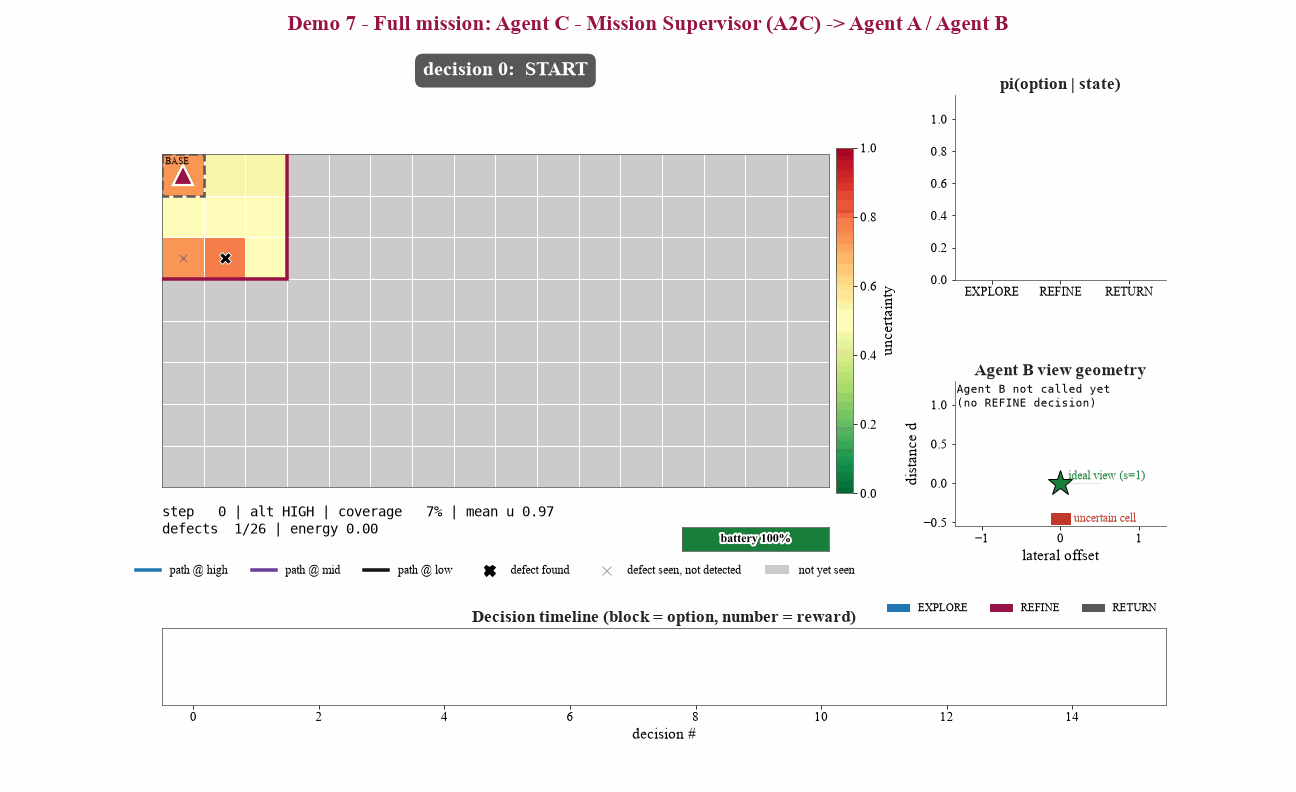

In [8]:
import demos.d7_full_mission as d7
d7.main(['--save'] + SEED)
show('full_mission.gif')

─────────────────────────────────────────────── DEMO 7 - Full hierarchical mission ───────────────────────────────────────────────

supervisor: RULE supervisor (scripted) | explore: Agent A - Viewpoint Planner (DQN) | refine: Agent B - View Refiner (PPO)

 GUIDELINE 1  InspectionEnv(mode='full', nav_policy=Agent A, refine_policy=Agent B), seed 1000

 GUIDELINE 2  Supervisor state before decision 0

OBSERVATION  s_t (6 numbers in [0, 1])                                 
┏━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ battery ┃ coverage ┃ mean u ┃ found frac ┃ dist to base ┃ time used ┃
┡━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│   1.000 │    0.070 │  0.971 │      0.038 │        0.000 │     0.000 │
└─────────┴──────────┴────────┴────────────┴──────────────┴───────────┘

...

saved full_mission_rule.gif (0.9 MB, 94 frames, 35s)

 GUIDELINE 8  Final performance: learned hierarchy vs fully scripted system, same bridge

supervisor option counts: {'EXPLORE': 21, 'REFINE': 10, 'RETURN': 1}

Seed 1000: live                                                                                                             
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━┓
┃ system                              ┃ decisions ┃ UAV moves ┃ return ┃ defects ┃ coverage ┃ energy ┃  mIoU ┃ safe return ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━┩
│ RULE supervisor (scripted) + A + B  │        32 │       141 │ +49.55 │   26/26 │     100% │  0.908 │ 0.629 │         yes │
│ ALL SCRIPTED (rule+raster+approach) │        34 │       149 │ +49.52 │   26/26 │     100% │  0.962 │ 0.595 │         yes │
└─────────────────────────────────────┴───────────┴───────────┴────────┴─────────┴──────────┴────────┴───────┴─────────────┘

Saved evaluation (mean of 20 seeded bridges) - full_mode_results.csv                                                 
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━┳━━━━━━━━┓
┃ config                                  ┃      return ┃ success ┃ decisions ┃ coverage ┃ defects ┃  mIoU ┃ energy ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━╇━━━━━━━━┩
│ ALL LEARNED  (C + A + B)                │ 40.9 +- 3.4 │    100% │      17.2 │     100% │    21.5 │ 0.528 │  0.517 │
│ ALL SCRIPTED (rule + raster + approach) │ 42.8 +- 3.0 │    100% │      33.8 │     100% │    22.6 │ 0.597 │  0.954 │
│ ablation: C learned, A/B scripted       │ 39.8 +- 3.4 │    100% │      19.2 │     100% │    20.9 │ 0.500 │  0.510 │
│ ablation: rule C, A + B learned         │ 44.8 +- 3.8 │    100% │      32.0 │     100% │    23.6 │ 0.623 │  0.925 │
└─────────────────────────────────────────┴─────────────┴─────────┴───────────┴──────────┴─────────┴───────┴────────┘

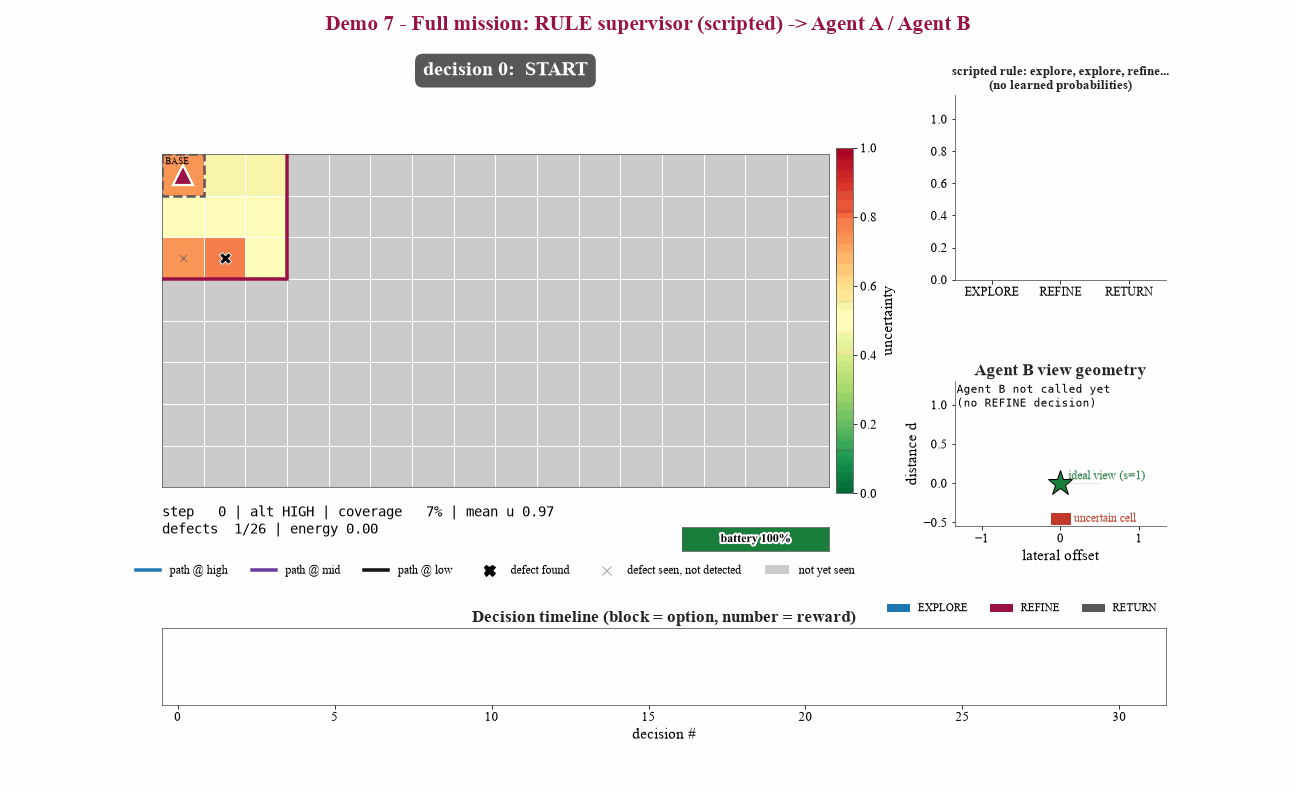

In [9]:
d7.main(['--save', '--supervisor', 'rule'] + SEED)
show('full_mission_rule.gif')

## Demo 8 - Learning burst: the update step (guideline 6)

──────────────────────────────── DEMO 8 - Learning burst: DQN (Agent A - Viewpoint Planner (DQN)) ────────────────────────────────

5000 steps, fresh network, output -> C:\Users\leekh\AppData\Local\Temp\uav_demo_burst\agentA_burst_1790619511

 GUIDELINE 1  Fresh environment (mode='navigate') wrapped in a Monitor

 GUIDELINE 6  DQN: act epsilon-greedy, store (s,a,r,s') in replay, every 4 steps a TD update

UPDATE step   304 | ep reward (mean) -12.8347 | epsilon +0.8845

...

DQN update on one sampled transition: loss = Huber(y - Q(s,a)), gradient step on      
Q-network                                                                             
┏━━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃ r      ┃ gamma ┃ done ┃ max Q_target(s',.) ┃ TD target y ┃ Q(s,a) ┃ TD error y - Q ┃
┡━━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━┩
│ -0.060 │ 0.995 │    0 │             +0.290 │      +0.228 │ +0.394 │         -0.166 │
└────────┴───────┴──────┴────────────────────┴─────────────┴────────┴────────────────┘

trained 5000 steps in 18.5s; 29 episodes; 11 logged updates

saved burst model -> C:\Users\leekh\AppData\Local\Temp\uav_demo_burst\agentA_burst_1790619511\agentA_burst.zip

real trained models untouched: True

This short run is NOT the trained agent: the real model trained for 200k steps (see demo 9 for its curves).

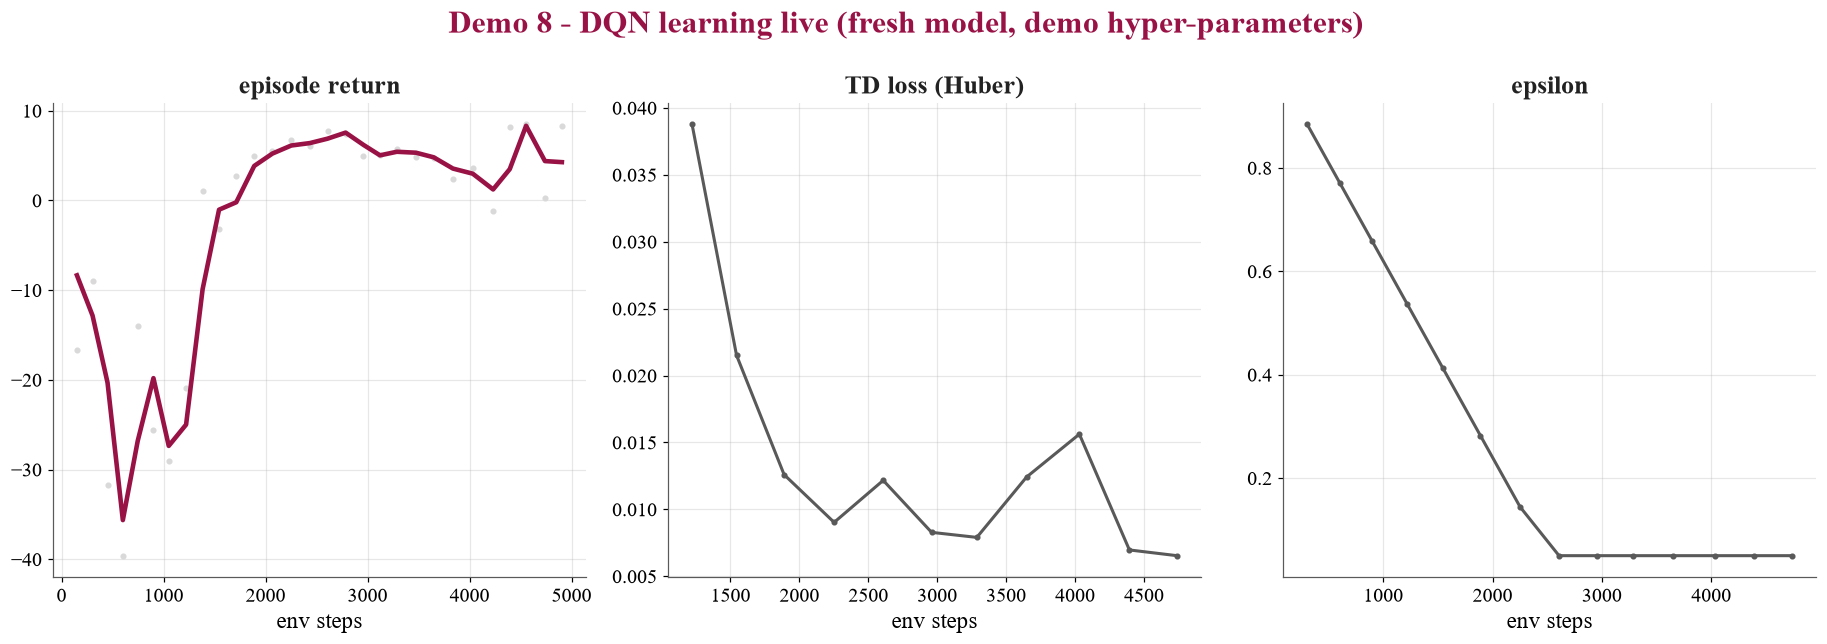

In [10]:
import demos.d8_learning_burst as d8
d8.main(['--save', '--agent', 'A'] + SEED)
show('learning_burst_A.png')

## Demo 9 - Learning curves and final metrics from the saved results (guideline 8)

─────────────────────────────────────────────────── DEMO 9 - Results dashboard ───────────────────────────────────────────────────

every number below is read from the saved result files

 GUIDELINE 8  Learning curves and final performance metrics

Agent A - Viewpoint Planner (DQN) vs baselines - agentA                                
┏━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━┳━━━━━━━━┓
┃ policy        ┃      return ┃ success ┃ steps ┃ coverage ┃ defects ┃  mIoU ┃ energy ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━╇━━━━━━━━┩
│ DQN (Agent A) │ 35.1 +- 4.0 │    100% │  88.3 │     100% │    21.8 │ 0.539 │  0.502 │
│ raster_mid    │  6.2 +- 0.1 │      0% │ 199.0 │     100% │    20.9 │ 0.500 │  1.000 │
│ raster_low    │ 35.4 +- 0.1 │    100% │ 123.0 │      95% │    23.5 │ 0.626 │  0.625 │
└───────────────┴─────────────┴─────────┴───────┴──────────┴─────────┴───────┴────────┘

Agent A - Viewpoint Planner (DQN): all saved runs (agent row of each *_vs_baselines.csv)                                          
┏━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ run            ┃ trained ┃                    setting ┃ return ┃ success ┃ steps ┃ energy ┃                               note ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ main           │    200k │ analytic, eps_fraction=0.3 │ +35.06 │    100% │  88.3 │  0.502 │                           full run │
│ agentA_eps0.1  │    150k │ analytic, eps_fraction=0.1 │ +37.78 │    100% │  74.7 │  0.397 │ short run: 150k steps (main: 200k) │
│ agentA_eps0.3  │    150k │ analytic, eps_fraction=0.3 │ +34.47 │    100% │  92.7 │  0.520 │ short run: 150k steps (main: 200k) │
│ agentA_eps0.6  │    150k │ analytic, eps_fraction=0.6 │ +28.09 │     80% │ 120.7 │  0.637 │ short run: 150k steps (main: 200k) │
│ agentA_learned │    500k │  learned, eps_fraction=0.3 │ +15.27 │     25% │ 151.6 │  0.909 │                           full run │
└────────────────┴─────────┴────────────────────────────┴────────┴─────────┴───────┴────────┴────────────────────────────────────┘

...

Agent C - Mission Supervisor (A2C) vs baselines - agentC                                     
┏━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━┳━━━━━━━━┓
┃ policy          ┃      return ┃ success ┃ decisions ┃ coverage ┃ defects ┃  mIoU ┃ energy ┃
┡━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━╇━━━━━━━━┩
│ A2C (Agent C)   │ 39.8 +- 3.4 │    100% │      19.2 │     100% │    20.9 │ 0.500 │  0.510 │
│ rule_supervisor │ 42.8 +- 3.0 │    100% │      33.8 │     100% │    22.6 │ 0.597 │  0.954 │
│ random          │  4.1 +- 9.1 │    100% │       3.0 │      16% │     3.0 │ 0.072 │  0.066 │
└─────────────────┴─────────────┴─────────┴───────────┴──────────┴─────────┴───────┴────────┘

Agent C - Mission Supervisor (A2C): all saved runs (agent row of each *_vs_baselines.csv)                                
┏━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ run            ┃ trained ┃            setting ┃ return ┃ success ┃ steps ┃ energy ┃                              note ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ main           │    100k │ analytic, ent=0.01 │ +39.84 │    100% │  19.2 │  0.510 │                          full run │
│ agentC_ent0.0  │     60k │  analytic, ent=0.0 │ +39.92 │    100% │  13.2 │  0.350 │ short run: 60k steps (main: 100k) │
│ agentC_ent0.01 │     60k │ analytic, ent=0.01 │ +40.86 │    100% │  17.8 │  0.475 │ short run: 60k steps (main: 100k) │
│ agentC_ent0.05 │     60k │ analytic, ent=0.05 │ +40.49 │    100% │  16.4 │  0.424 │ short run: 60k steps (main: 100k) │
│ agentC_learned │    100k │  learned, ent=0.01 │ +41.12 │    100% │  13.4 │  0.350 │                          full run │
│ agentC_withA   │    100k │ analytic, ent=0.01 │ +43.68 │    100% │  29.9 │  0.844 │                          full run │
└────────────────┴─────────┴────────────────────┴────────┴─────────┴───────┴────────┴───────────────────────────────────┘

Full hierarchy - full_mode_results.csv                                                                               
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━┳━━━━━━━━┓
┃ config                                  ┃      return ┃ success ┃ decisions ┃ coverage ┃ defects ┃  mIoU ┃ energy ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━╇━━━━━━━━┩
│ ALL LEARNED  (C + A + B)                │ 40.9 +- 3.4 │    100% │      17.2 │     100% │    21.5 │ 0.528 │  0.517 │
│ ALL SCRIPTED (rule + raster + approach) │ 42.8 +- 3.0 │    100% │      33.8 │     100% │    22.6 │ 0.597 │  0.954 │
│ ablation: C learned, A/B scripted       │ 39.8 +- 3.4 │    100% │      19.2 │     100% │    20.9 │ 0.500 │  0.510 │
│ ablation: rule C, A + B learned         │ 44.8 +- 3.8 │    100% │      32.0 │     100% │    23.6 │ 0.623 │  0.925 │
└─────────────────────────────────────────┴─────────────┴─────────┴───────────┴──────────┴─────────┴───────┴────────┘

ALL LEARNED vs ALL SCRIPTED (saved means): decisions -49%, energy -46%, return -1.88, defects -1.05

PNG + CSV exported to L:\My Drive\RL_Project\files_coding\Live_Demo\backup\snapshots

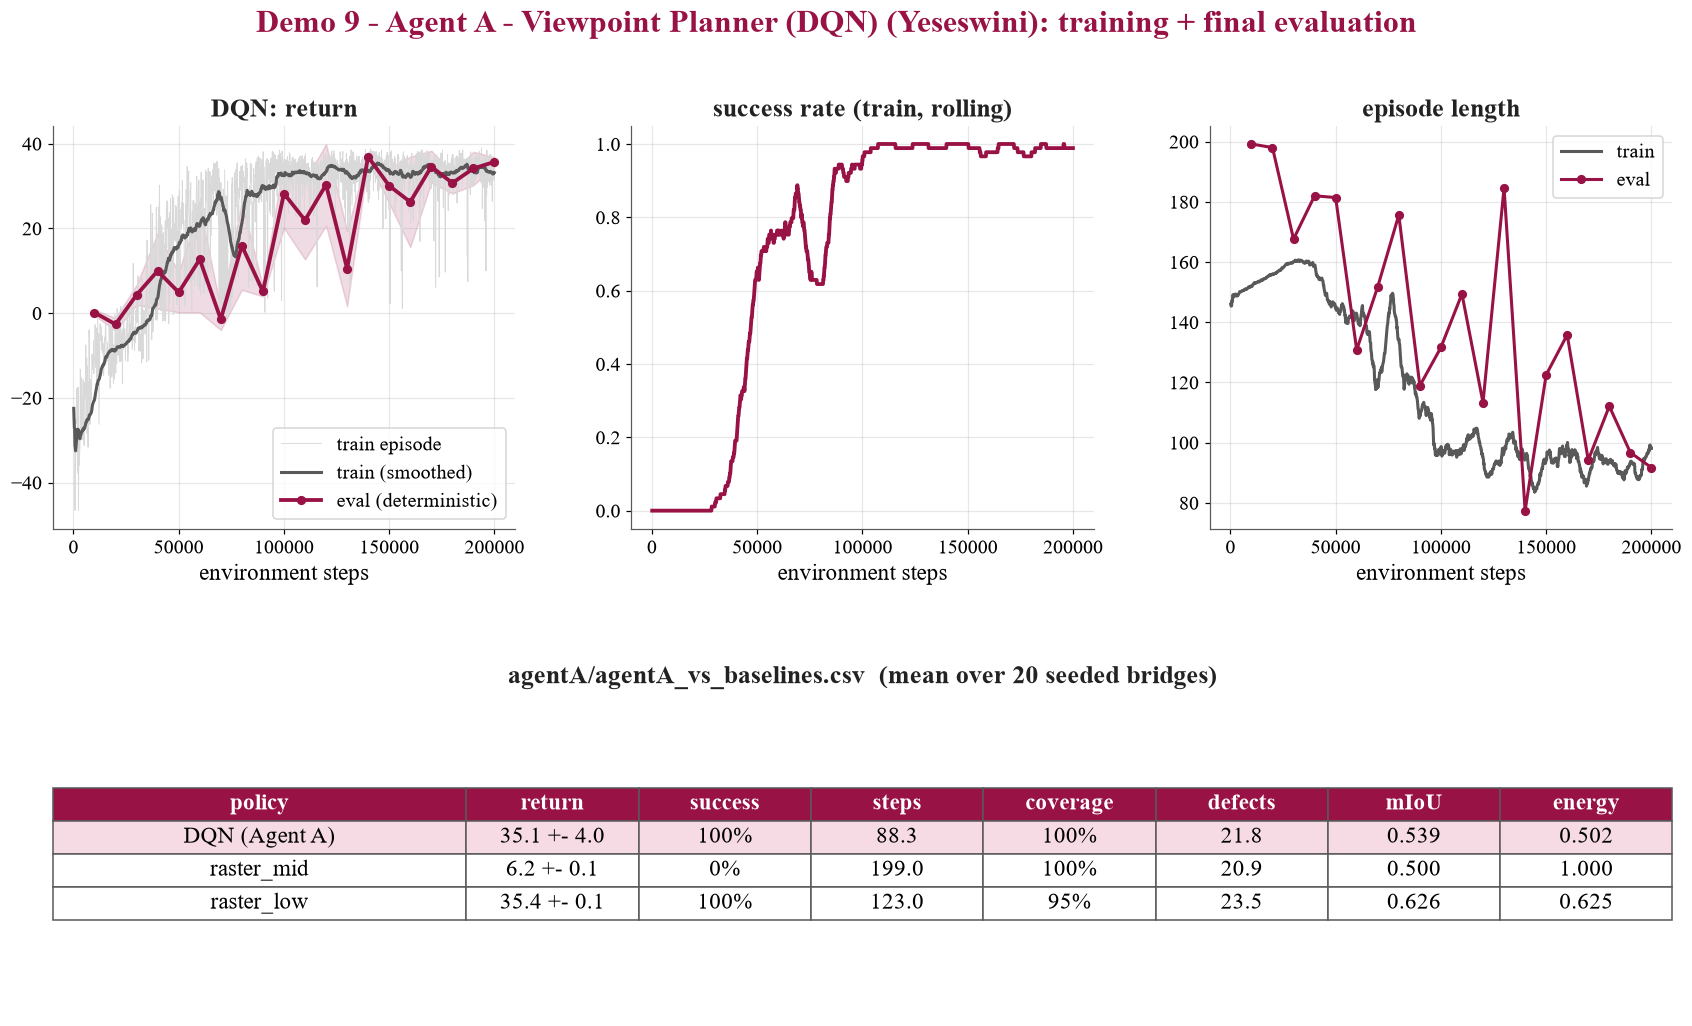

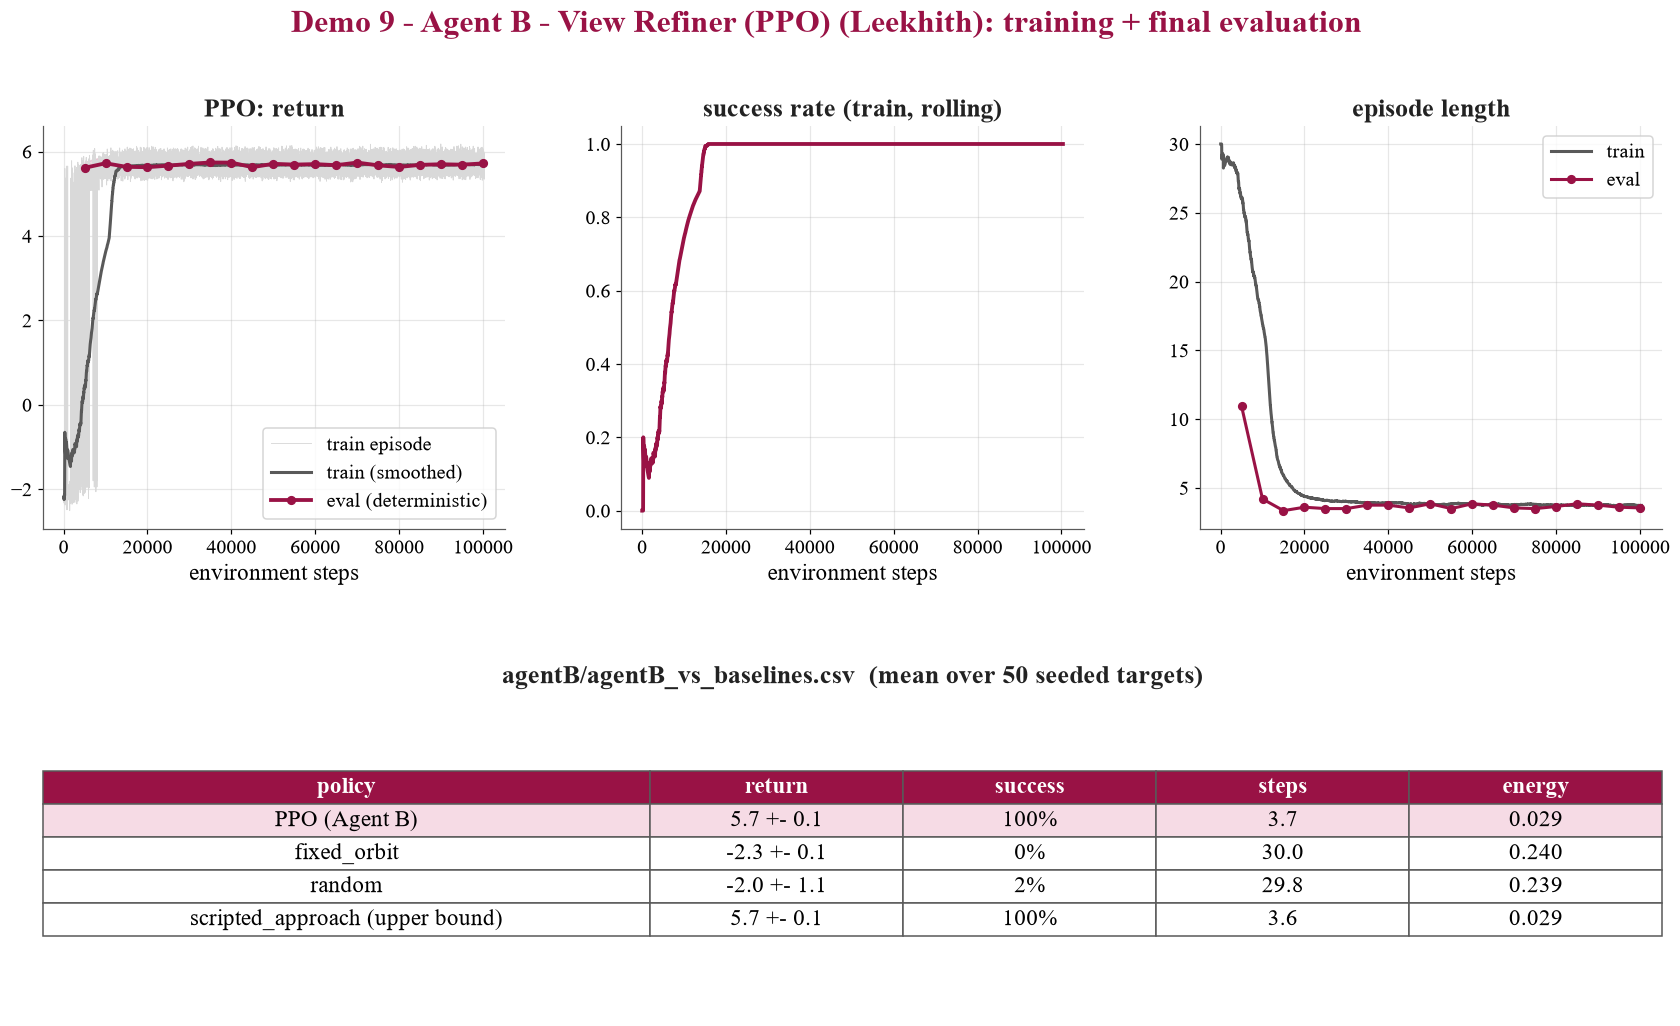

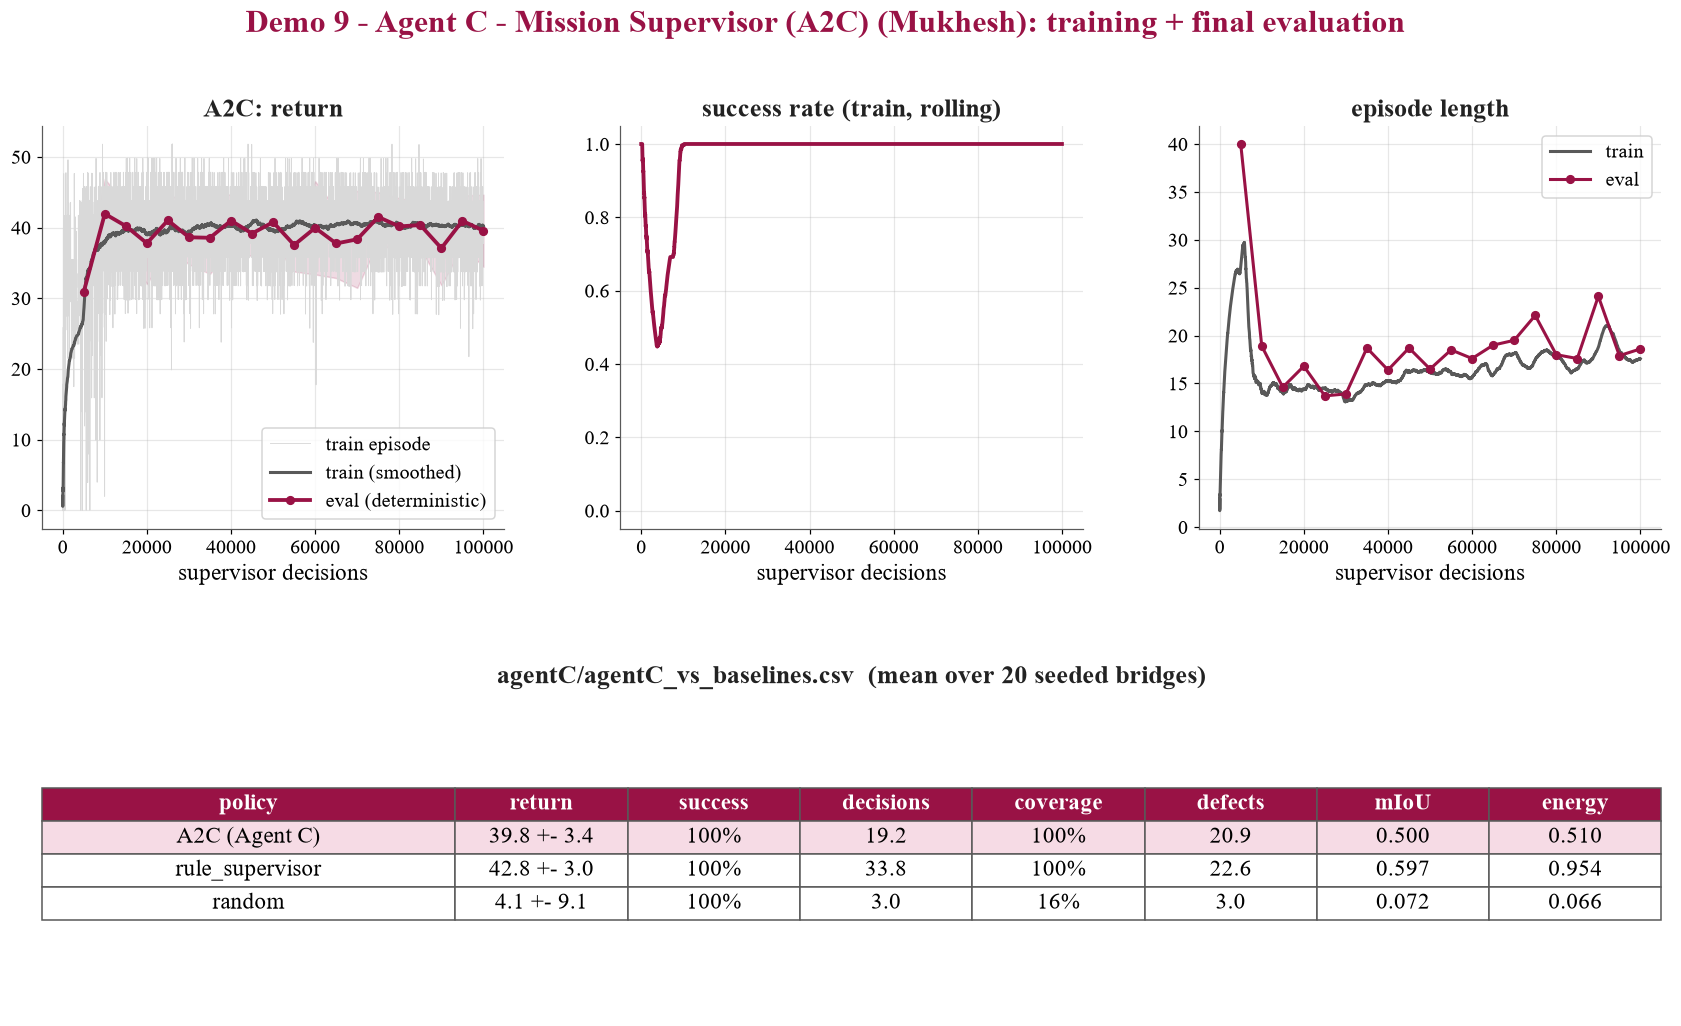

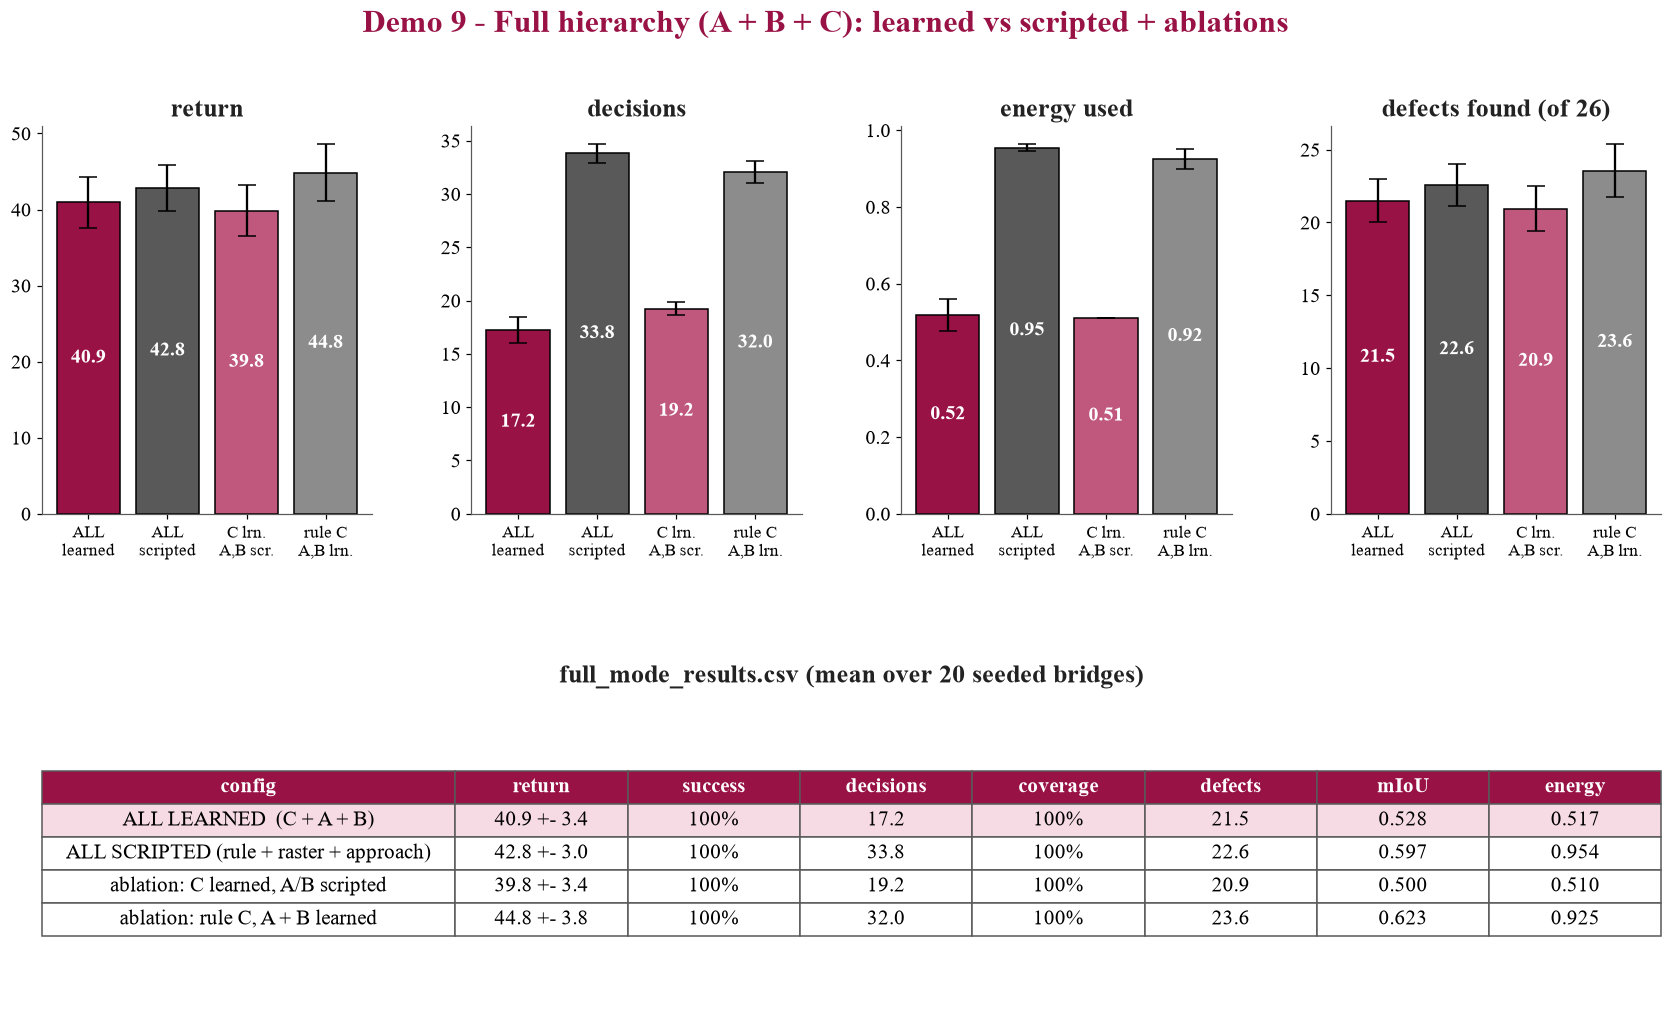

In [11]:
import demos.d9_results_dashboard as d9
d9.main(['--headless'] + SEED)
show('results_A.png')
show('results_B.png')
show('results_C.png')
show('results_full.png')